# Lab 7: Optimisation and Regularisation — the Second Iteration

## ✅ Solution version

All `???` gaps are filled in, and a **Solution and discussion** box follows every set of questions. The outputs and numbers come from our reference runs on a Colab T4 GPU. Your own numbers will differ somewhat (GPU non-determinism, see Lab 6). What matters is whether you can explain the patterns you observe.

**Before you start: Runtime → Change runtime type → GPU.**

Lab 6 ended with a clear diagnosis. The final model (DeepCNN with Kaiming initialisation and batch
norm) reached a training loss of about **0.01** but a validation loss of about **0.45**. It
memorised the training set. Overfitting is the top issue, so this lab is the **second trip around the
loop**, using this week's lecture as the toolbox.

This lecture contains a *lot* of techniques. The point of the lab is **not** to switch them all on,
and it is not to find the highest accuracy. It is to understand how each technique works (by
implementing it), to test each as a **single change**, and above all to **understand and explain the
results you observe, including the ones you didn't expect**. A technique can do exactly what it is
designed to do and still not improve accuracy in a given setting (too few epochs, too little data,
a dataset where the technique doesn't fit…). Being able to explain *why* is what your project report
needs, and it is what this lab practises.

### ⚠️ Know the limits of this lab

To fit into three hours, everything here is deliberately small:

- **A toy network:** a 9-layer CNN with about 0.5 million parameters, trained from scratch.
- **A toy dataset:** 32×32 SVHN crops; 10,000 training images (only 2,000 in Part 5) and a 2,000-image
  validation set. On its own, that validation set has a standard error of about ±0.7 percentage points.
- **Short training budgets:** 5–30 epochs. Published SVHN results typically train for 100 epochs or more.
- **Few seeds:** 2 per configuration. Enough to *see* the noise, not enough to measure small effects.
- **One dataset with quirks:** neighbouring digits at the image edges, and a long initial plateau.

So every conclusion you draw today is a conclusion about **this setup**. "Label smoothing lowered
accuracy" means "in this network, on this data, at this budget". It does not mean the technique is
useless, and it does not predict what will happen in your project. **Don't carry the numbers into
your project; carry the method:** predict, change one thing, measure both the mechanism and the
outcome, and explain the difference.

| Part | You will… | Time |
|---|---|---|
| 1. Diagnosis + early stopping | implement early stopping, then diagnose the Lab 6 model over a longer run | 20 min |
| 2. Optimisers | implement SGD, momentum and Adam; compare them on a 2-D ravine and on SVHN | 35 min |
| 3. LR range test | implement the range test and compare it with a full sweep | 15 min |
| 4. Learning-rate schedules | implement cosine decay with warm-up; test whether warm-up rescues a learning rate that's too high | 20 min |
| 5. Regularisation | implement Mixup and Cutout; test what each regulariser does, and explain whether that improves accuracy | 40 min |
| 6. Ensembles | implement an ensemble of the models you have already trained (no extra training) | 10 min |
| 7. The final test | choose a final model and evaluate it on the test set — exactly once | 10 min |

Then complete this week's pages in your **iteration log** (`Lab7_IterationLog_Week7.md`) for your
own project.

**Cells marked 🛠️ TASK contain gaps (`???`) that you must fill in.** Most tasks come with a test
cell. Don't move on until the tests pass. As in Lab 6, write down your ✍️ **Prediction** before
running an experiment.

**Short on time?** Parts 1, 2, 3, 5 and 7 are the core. Part 4's experiment can be finished at home.

## Setup (same data, models and helpers as Lab 6)

In [33]:
import copy
import math
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True   # let cuDNN pick the fastest convolution algorithms (a free speed-up)
print(f'Using device: {device}')


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


N_TRAIN, N_VAL = 10_000, 2_000
BATCH_SIZE = 64
NUM_CLASSES = 10
EPOCHS = 10

svhn = torchvision.datasets.SVHN(root='./data', split='train', download=True)
perm = torch.randperm(len(svhn), generator=torch.Generator().manual_seed(0))
train_idx, val_idx = perm[:N_TRAIN], perm[N_TRAIN:N_TRAIN + N_VAL]


def load_subset(dataset, idx):
    x = torch.from_numpy(dataset.data[idx.numpy()]).float() / 255.0
    y = torch.from_numpy(np.asarray(dataset.labels)[idx.numpy()]).long()
    return x, y


x_train, y_train = load_subset(svhn, train_idx)
x_val, y_val = load_subset(svhn, val_idx)
MEAN = x_train.mean(dim=(0, 2, 3), keepdim=True)
STD = x_train.std(dim=(0, 2, 3), keepdim=True)
x_train = ((x_train - MEAN) / STD).to(device)
x_val = ((x_val - MEAN) / STD).to(device)
y_train, y_val = y_train.to(device), y_val.to(device)

# A fixed 2,000-image slice of the training set, used to measure the training loss *without*
# augmentation, Mixup, dropout etc. -- so that training losses are comparable between experiments.
x_train_eval, y_train_eval = x_train[:N_VAL], y_train[:N_VAL]
print(f'Train: {tuple(x_train.shape)}, Val: {tuple(x_val.shape)}')

Using device: cuda
Train: (10000, 3, 32, 32), Val: (2000, 3, 32, 32)


In [34]:
def random_shift(xb, max_shift=4):
    '''Augmentation: shift each image by up to `max_shift` pixels (as in Lab 6).'''
    n, _, h, w = xb.shape
    shifts = torch.randint(-max_shift, max_shift + 1, (n, 2), device=xb.device).float()
    theta = torch.zeros(n, 2, 3, device=xb.device)
    theta[:, 0, 0] = 1
    theta[:, 1, 1] = 1
    theta[:, 0, 2] = shifts[:, 0] * 2 / w
    theta[:, 1, 2] = shifts[:, 1] * 2 / h
    grid = F.affine_grid(theta, xb.shape, align_corners=False)
    return F.grid_sample(xb, grid, padding_mode='zeros', align_corners=False)


def batches(x, y, batch_size=BATCH_SIZE, shuffle=True):
    order = torch.randperm(len(x), device=x.device) if shuffle else torch.arange(len(x), device=x.device)
    for i in range(0, len(x), batch_size):
        idx = order[i:i + batch_size]
        yield x[idx], y[idx]


class DeepCNN(nn.Module):
    '''Lab 6's DeepCNN (3 stages x 3 conv layers), now with optional dropout before the classifier.'''
    def __init__(self, num_classes=NUM_CLASSES, widths=(32, 64, 128), convs_per_stage=3,
                 batchnorm=True, dropout=0.0):
        super().__init__()
        layers, in_ch = [], 3
        for out_ch in widths:
            for _ in range(convs_per_stage):
                layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=not batchnorm))
                if batchnorm:
                    layers.append(nn.BatchNorm2d(out_ch))
                layers.append(nn.ReLU())
                in_ch = out_ch
            layers.append(nn.MaxPool2d(2, 2))
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(dropout),
                                        nn.Linear(widths[-1] * 4 * 4, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


def build_model(init='kaiming', batchnorm=True, dropout=0.0):
    model = DeepCNN(batchnorm=batchnorm, dropout=dropout)
    if init == 'kaiming':
        for m in model.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    return model.to(device)


plain_ce = nn.CrossEntropyLoss()   # evaluation always uses plain cross-entropy, whatever the training loss


@torch.no_grad()
def evaluate(model, x, y, batch_size=512):
    model.eval()
    total_loss, correct = 0.0, 0
    for xb, yb in batches(x, y, batch_size=batch_size, shuffle=False):
        logits = model(xb)
        total_loss += plain_ce(logits, yb).item() * len(xb)
        correct += (logits.argmax(1) == yb).sum().item()
    return total_loss / len(x), correct / len(x)

### The training harness

`run_experiment` is the Lab 6 version, extended with everything from this week's lecture. Every
setting lives in the configuration. Anything you don't override keeps its default value from
`DEFAULT_CONFIG` (the Lab 6 final model trained with SGD + momentum, lr = 0.01).

Three details to notice:

- After every epoch, the training loss is **re-measured on clean training images** (`x_train_eval`,
  model in eval mode). The loss printed *during* training is computed on augmented/Mixup
  images with dropout active, so it isn't comparable between experiments. The clean one is.
- The harness keeps the **best epoch** (highest validation accuracy) using the `EarlyStopping`
  class that **you** implement in Task 1, and reports both the best and the final validation accuracy.
- It uses functions you will write later (`warmup_cosine`, `mixup`, `cutout`). Those are only called
  when the corresponding option is switched on, so the harness works from Part 1 onwards.
- At the end of each run, `mechanism_stats` records three quantities that regularisers are designed
  to change: the total **weight norm**, the mean **confidence** on validation images, and the
  **overconfidence** (confidence minus accuracy). You'll use them in Part 5.

You don't need to change this cell, but read it once.

In [35]:
DEFAULT_CONFIG = dict(optimizer='momentum', lr=0.01, weight_decay=0.0,
                      init='kaiming', batchnorm=True, dropout=0.0,
                      augment=False, cutout=False, mixup_alpha=0.0, label_smoothing=0.0,
                      schedule='constant', warmup_epochs=0, train_size=None)   # train_size=None: all N_TRAIN images
EXPERIMENT_LOG, HISTORIES, MODELS = [], {}, {}


def make_optimizer(name, params, lr, weight_decay=0.0):
    if name == 'sgd':
        return torch.optim.SGD(params, lr=lr, momentum=0.0, weight_decay=weight_decay)
    if name == 'momentum':
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    if name == 'adam':
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(name)


def train_one_epoch(model, optimizer, scheduler, cfg, criterion):
    model.train()
    n = cfg['train_size'] or N_TRAIN
    for xb, yb in batches(x_train[:n], y_train[:n]):
        if cfg['augment']:
            xb = random_shift(xb)
        if cfg['cutout']:
            xb = cutout(xb)
        optimizer.zero_grad()
        if cfg['mixup_alpha'] > 0:
            x_mix, y_a, y_b, lam = mixup(xb, yb, cfg['mixup_alpha'])
            logits = model(x_mix)
            loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)
        else:
            loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()                     # per-batch schedule
        if not torch.isfinite(loss):
            return False
    return True


@torch.no_grad()
def mechanism_stats(model, x, y, batch_size=512):
    '''What regularisers are *supposed* to change, measured directly (used in Part 5).'''
    model.eval()
    conf_sum, correct = 0.0, 0
    for xb, yb in batches(x, y, batch_size=batch_size, shuffle=False):
        p = F.softmax(model(xb), dim=1)
        conf_sum += p.max(dim=1).values.sum().item()
        correct += (p.argmax(dim=1) == yb).sum().item()
    conf, acc = conf_sum / len(x), correct / len(x)
    weight_norm = math.sqrt(sum((m.weight ** 2).sum().item()
                                for m in model.modules() if isinstance(m, (nn.Conv2d, nn.Linear))))
    return dict(weight_norm=weight_norm,          # total L2 norm of all conv/linear weights
                val_confidence=conf,              # mean max-softmax probability on validation images
                overconfidence=conf - acc)        # > 0: the model is more confident than it is accurate


def run_experiment(name, seed=0, epochs=EPOCHS, patience=None, verbose=True, keep_model=True, **overrides):
    '''Trains one model; restores its best epoch (by val. accuracy); logs everything. Returns (model, history).'''
    cfg = dict(DEFAULT_CONFIG)
    unknown = set(overrides) - set(cfg)
    assert not unknown, f'Unknown config keys: {unknown}'
    cfg.update(overrides)
    set_seed(seed)
    model = build_model(cfg['init'], cfg['batchnorm'], cfg['dropout'])
    optimizer = make_optimizer(cfg['optimizer'], model.parameters(), cfg['lr'], cfg['weight_decay'])
    steps_per_epoch = math.ceil((cfg['train_size'] or N_TRAIN) / BATCH_SIZE)
    scheduler = None
    if cfg['schedule'] == 'cosine':
        total, warm = epochs * steps_per_epoch, cfg['warmup_epochs'] * steps_per_epoch
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda s: warmup_cosine(s, total, warm))
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg['label_smoothing'])
    stopper = EarlyStopping(patience=patience if patience is not None else 10 ** 9, mode='max')

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    diverged, start = False, time.time()
    for epoch in range(epochs):
        history['lr'].append(optimizer.param_groups[0]['lr'])
        if not train_one_epoch(model, optimizer, scheduler, cfg, criterion):
            diverged = True
            break
        tr_loss, _ = evaluate(model, x_train_eval, y_train_eval)
        va_loss, va_acc = evaluate(model, x_val, y_val)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        if stopper.step(va_acc, model, epoch):
            break
    runtime = time.time() - start
    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    result = dict(name=name, seed=seed, **cfg, epochs_run=len(history['val_acc']), diverged=diverged,
                  best_epoch=(stopper.best_epoch + 1) if stopper.best_epoch is not None else None,
                  best_val_acc=stopper.best if stopper.best is not None else float('nan'),
                  final_val_acc=history['val_acc'][-1] if history['val_acc'] else float('nan'),
                  final_train_loss=history['train_loss'][-1] if history['train_loss'] else float('nan'),
                  final_val_loss=history['val_loss'][-1] if history['val_loss'] else float('nan'),
                  runtime_s=round(runtime, 1))
    result.update(mechanism_stats(model, x_val, y_val) if history['val_acc'] else
                  dict(weight_norm=float('nan'), val_confidence=float('nan'), overconfidence=float('nan')))
    EXPERIMENT_LOG.append(result)
    pd.DataFrame(EXPERIMENT_LOG).to_csv('experiment_log_lab7.csv', index=False)
    HISTORIES[(name, seed)] = history
    if keep_model:
        MODELS[(name, seed)] = model
    if verbose:
        if diverged:
            print(f'  [{name} | seed {seed}] diverged in epoch {len(history["val_acc"]) + 1}')
        elif result['best_val_acc'] < 0.25:
            print(f'  [{name} | seed {seed}] WARNING: stuck at the majority class (best val acc '
                  f'{result["best_val_acc"]:.3f}) -- the network never escaped the plateau or died early. '
                  f'This says nothing about the technique you are testing; check the learning rate first.')
        else:
            print(f'  [{name} | seed {seed}] best val acc {result["best_val_acc"]:.3f} (epoch {result["best_epoch"]}) | '
                  f'final val acc {result["final_val_acc"]:.3f} | clean train loss {result["final_train_loss"]:.3f} | '
                  f'val loss {result["final_val_loss"]:.3f} | {runtime:.0f}s')
    return model, history


def summarise(names):
    df = pd.DataFrame(EXPERIMENT_LOG)
    df = df[df['name'].isin(names)]
    out = df.groupby('name', sort=False).agg(runs=('seed', 'count'),
                                             best_val_acc=('best_val_acc', 'mean'),
                                             best_val_acc_std=('best_val_acc', 'std'),
                                             final_val_acc=('final_val_acc', 'mean'),
                                             best_epoch=('best_epoch', 'mean'),
                                             train_loss=('final_train_loss', 'mean'),
                                             val_loss=('final_val_loss', 'mean'),
                                             weight_norm=('weight_norm', 'mean'),
                                             val_confidence=('val_confidence', 'mean'),
                                             overconfidence=('overconfidence', 'mean'))
    out['gap (val - train loss)'] = out['val_loss'] - out['train_loss']
    return out.reindex([n for n in names if n in out.index]).round(4)

---
## Part 1: Diagnosis and early stopping

The lecture says "always do early stopping": keep track of the model snapshot that did best on the
validation set. Our harness needs this, so it's your first task.

### 🛠️ Task 1 — implement `EarlyStopping`

Call `step(value, model, epoch)` once per epoch with the monitored validation value. It must:

1. decide whether `value` is an **improvement** on the best value so far (higher is better when
   `mode='max'`, lower when `mode='min'`);
2. on improvement: store the value, the epoch and a **deep copy** of the model's `state_dict()`, and
   reset the counter of epochs without improvement;
3. otherwise: increase that counter;
4. return `True` (stop training) once the counter reaches `patience`.

**Why a deep copy?** `model.state_dict()` returns references to the live tensors. Without a copy,
your "best" snapshot would keep changing as training continues.

In [36]:
class EarlyStopping:
    def __init__(self, patience=5, mode='max'):
        assert mode in ('max', 'min')
        self.patience = patience
        self.mode = mode
        self.best = None          # best monitored value so far
        self.best_epoch = None    # epoch (0-based) at which it occurred
        self.best_state = None    # deep copy of the model's state_dict at that epoch
        self.bad_epochs = 0       # consecutive epochs without improvement

    def step(self, value, model, epoch):
        '''Call once per epoch. Returns True if training should stop.'''
        if self.best is None:
            improved = True
        elif self.mode == 'max':
            improved = value > self.best
        else:
            improved = value < self.best

        if improved:
            self.best = value
            self.best_epoch = epoch
            self.best_state = copy.deepcopy(model.state_dict())
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1
        return self.bad_epochs >= self.patience

In [37]:
# Tests for Task 1 -- run this cell; it should print 'All EarlyStopping tests passed.'
dummy = nn.Linear(1, 1)
es = EarlyStopping(patience=3, mode='max')
values = [0.50, 0.60, 0.70, 0.65, 0.66, 0.64, 0.90]
stopped_at = None
for epoch, v in enumerate(values):
    with torch.no_grad():
        dummy.weight.fill_(epoch)             # "training" changes the weights every epoch
    if es.step(v, dummy, epoch):
        stopped_at = epoch
        break
assert stopped_at == 5, f'should stop at epoch 5 (3 epochs without improvement), stopped at {stopped_at}'
assert es.best == 0.70 and es.best_epoch == 2, (es.best, es.best_epoch)
assert es.best_state['weight'].item() == 2, 'best_state must be a snapshot from epoch 2 -- did you deep-copy it?'

es_min = EarlyStopping(patience=2, mode='min')
for epoch, v in enumerate([1.0, 0.8, 0.9, 0.7, 0.75, 0.72]):
    if es_min.step(v, dummy, epoch):
        break
assert es_min.best == 0.7 and es_min.best_epoch == 3 and epoch == 5, (es_min.best, es_min.best_epoch, epoch)
print('All EarlyStopping tests passed.')

All EarlyStopping tests passed.


### The diagnosis

Now train the Lab 6 final model (`DEFAULT_CONFIG`) for **20 epochs**, without early stopping, and
look at the curves.

✍️ **Prediction:** at which epoch will the validation **loss** be lowest? And the validation
**accuracy** highest? The same epoch?

  [D0_lab6_final_20ep | seed 0] best val acc 0.901 (epoch 12) | final val acc 0.896 | clean train loss 0.001 | val loss 0.488 | 40s


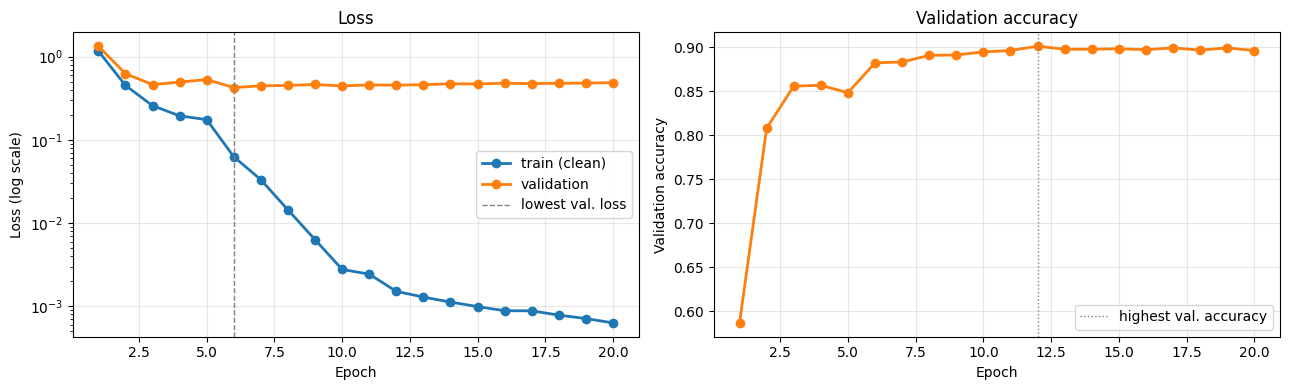

Lowest val. loss at epoch 6, highest val. accuracy at epoch 12


In [38]:
_, h_diag = run_experiment('D0_lab6_final_20ep', epochs=20)

ep = range(1, len(h_diag['val_acc']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(ep, h_diag['train_loss'], 'o-', lw=2, label='train (clean)')
ax1.plot(ep, h_diag['val_loss'], 'o-', lw=2, label='validation')
ax1.axvline(int(np.argmin(h_diag['val_loss'])) + 1, color='gray', ls='--', lw=1, label='lowest val. loss')
ax1.set_yscale('log'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss (log scale)')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, h_diag['val_acc'], 'o-', lw=2, color='C1')
ax2.axvline(int(np.argmax(h_diag['val_acc'])) + 1, color='gray', ls=':', lw=1, label='highest val. accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Validation accuracy'); ax2.set_title('Validation accuracy')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Lowest val. loss at epoch {int(np.argmin(h_diag["val_loss"])) + 1}, '
      f'highest val. accuracy at epoch {int(np.argmax(h_diag["val_acc"])) + 1}')

**Questions:**

1. Which of the lecture's train-vs-validation curve patterns (slides 90–92) does this match?
2. Why can the validation **loss** go up while validation **accuracy** stays flat or even improves?
   (Hint: what does cross-entropy punish that accuracy ignores?)
3. Should you early-stop on validation loss or on validation accuracy? Our harness uses accuracy.
   When would you choose the loss instead?
4. From the curves alone, list the candidate remedies from the lecture that address this diagnosis,
   and one remedy that would **not** help. (Keep the list. You'll test some in Part 5.)

> ### ✅ Solution and discussion
> **Reference runs (three runs of the same cell):** the clean training loss falls to **0.001**. The lowest validation loss is at **epoch 6–8**, after which validation loss rises to ≈ 0.49 by epoch 20. Validation accuracy levels off at ≈ 89.5–90% from about epoch 10 onwards (best 89.8–90.1%). Its argmax landed at epochs 10, **18** and 12 in the three runs: on a plateau, the "best" epoch is essentially chosen by noise. So the best-loss and best-accuracy epochs differ, which is the point of question 2.
>
> 1. This is the classic **overfitting** pattern: a growing gap between training and validation loss.
> 2. Cross-entropy punishes **confident** mistakes heavily, but accuracy only counts argmax errors. As the model memorises, it becomes extremely confident. The images it gets wrong are now wrong with ~100% confidence, so they cost a lot of loss, while the *number* of errors barely changes. Validation loss rising with flat accuracy = increasingly **overconfident** (miscalibrated) predictions.
> 3. Use **the metric you will report** (here accuracy) if that is what you care about. Use the **loss** when calibrated probabilities matter (e.g. medical risk scores, thresholds chosen afterwards, uncertainty), or when the accuracy is too noisy or coarse on a small validation set to pick an epoch reliably (as the epoch-10-vs-18 example shows). Either way: decide in advance and state it in the Methods section.
> 4. Remedies that match the diagnosis: early stopping, weight decay, dropout, data augmentation (shift, Cutout), Mixup, label smoothing (this one targets overconfidence directly), more data, a smaller model, ensembles. **Won't help:** anything aimed at *optimisation*, e.g. a different optimiser or a higher learning rate to "train faster" (the training loss is already ~0), or a bigger model (more capacity worsens memorisation).

---
## Part 2: Optimisers — from update rules to experiments

### 🛠️ Task 2a — implement the update rules

Implement the three update rules from the lecture. Each function receives the current parameters
`w`, the gradient `g` and a `state` dict (for velocity, moment estimates, step count…) that persists
between calls, and returns the **new** parameters.

Use PyTorch's formulation of momentum: **v ← ρ·v + g,  w ← w − η·v**. The lecture writes it as
v ← γ·v + η·g, w ← w − v. ✍️ *Are the two equivalent? When would they differ?*

For Adam, remember the **bias correction** of both moment estimates (slide 40).

In [39]:
def sgd_step(w, g, state, lr):
    return w - lr * g


def momentum_step(w, g, state, lr, rho=0.9):
    v = state.get('v', torch.zeros_like(w))
    v = rho * v + g
    state['v'] = v
    return w - lr * v


def adam_step(w, g, state, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    m = state.get('m', torch.zeros_like(w))
    v = state.get('v', torch.zeros_like(w))
    t = state.get('t', 0) + 1
    m = beta1 * m + (1 - beta1) * g                     # first moment (like momentum)
    v = beta2 * v + (1 - beta2) * g ** 2                # second moment (like RMSProp)
    m_hat = m / (1 - beta1 ** t)                        # bias correction
    v_hat = v / (1 - beta2 ** t)
    state.update(m=m, v=v, t=t)
    return w - lr * m_hat / (torch.sqrt(v_hat) + eps)

In [40]:
# Tests for Task 2a: your update rules must match torch.optim exactly on a random quadratic problem.
def compare_with_torch(my_step, torch_opt, my_kwargs, torch_kwargs, steps=50):
    gen = torch.Generator().manual_seed(0)
    A = torch.randn(5, 5, generator=gen, dtype=torch.float64)
    A = A @ A.T + 0.5 * torch.eye(5, dtype=torch.float64)            # positive definite
    b = torch.randn(5, generator=gen, dtype=torch.float64)
    w0 = torch.randn(5, generator=gen, dtype=torch.float64)

    w, state = w0.clone(), {}
    for _ in range(steps):
        w = my_step(w, A @ w - b, state, **my_kwargs)                # gradient of 0.5 w'Aw - b'w

    p = nn.Parameter(w0.clone())
    opt = torch_opt([p], **torch_kwargs)
    for _ in range(steps):
        opt.zero_grad()
        (0.5 * p @ A @ p - b @ p).backward()
        opt.step()
    assert torch.allclose(w, p.detach(), atol=1e-8), f'{my_step.__name__} does not match {torch_opt.__name__}'
    print(f'{my_step.__name__:<14} matches torch.optim.{torch_opt.__name__}')


compare_with_torch(sgd_step, torch.optim.SGD, dict(lr=0.05), dict(lr=0.05))
compare_with_torch(momentum_step, torch.optim.SGD, dict(lr=0.02, rho=0.9), dict(lr=0.02, momentum=0.9))
compare_with_torch(adam_step, torch.optim.Adam, dict(lr=0.1), dict(lr=0.1))

sgd_step       matches torch.optim.SGD
momentum_step  matches torch.optim.SGD
adam_step      matches torch.optim.Adam


### The ravine

The lecture's main argument for momentum: in a **ravine**, a surface that is much steeper in one
direction than another, SGD zig-zags across the steep direction while crawling along the flat one.
Let's watch your three optimisers on f(x, y) = 0.005·x² + y², which is 200 times steeper in y than in x.

✍️ **Prediction:** sketch the three paths before running the cell.

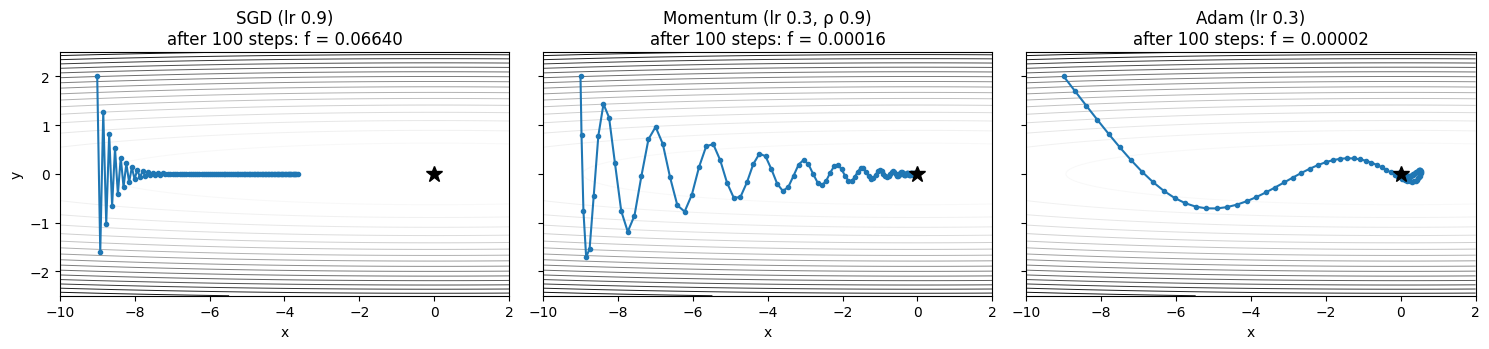

In [46]:
def ravine_grad(w):
    return torch.tensor([0.01 * w[0], 2.0 * w[1]])


def trajectory(step_fn, steps=100, **kwargs):
    w, state, path = torch.tensor([-9.0, 2.0]), {}, []
    for _ in range(steps):
        path.append(w.clone())
        w = step_fn(w, ravine_grad(w), state, **kwargs)
    path.append(w.clone())
    return torch.stack(path).numpy()


X, Y = np.meshgrid(np.linspace(-10, 2, 200), np.linspace(-2.5, 2.5, 200))
runs = [('SGD (lr 0.9)', trajectory(sgd_step, lr=0.9)),
        ('Momentum (lr 0.3, ρ 0.9)', trajectory(momentum_step, lr=0.3)),
        ('Adam (lr 0.3)', trajectory(adam_step, lr=0.3))]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, (label, path) in zip(axes, runs):
    ax.contour(X, Y, 0.005 * X ** 2 + Y ** 2, levels=20, cmap='Greys', linewidths=0.7)
    ax.plot(path[:, 0], path[:, 1], 'o-', ms=3, lw=1.5, color='C0')
    ax.plot(0, 0, 'k*', ms=12)
    ax.set_title(f'{label}\nafter 100 steps: f = {0.005 * path[-1, 0] ** 2 + path[-1, 1] ** 2:.5f}')
    ax.set_xlabel('x')
axes[0].set_ylabel('y')
plt.tight_layout(); plt.show()

**Questions:**

1. Describe each path. Where does SGD waste its steps? What does momentum do with the oscillations in y?
2. Adam's first steps go roughly **diagonally**, even though the gradient points mostly in y. Explain
   this from the update rule. (What is m̂/√v̂ when the gradient has had a constant sign so far?)
3. Try `sgd_step` with lr = 1.05. What happens, and why exactly at about 1? (Hint: the update in y is
   y ← (1 − 2·lr)·y.)

> ### ✅ Solution and discussion
> 1. **SGD** zig-zags across the ravine (y alternates sign: y ← (1 − 1.8)·y = −0.8·y) and crawls in x: x ← (1 − 0.9·0.01)·x = 0.991·x per step, so after 100 steps it has covered less than two-thirds of the distance (reference: f ≈ 0.066). The learning rate can't be raised, because the steep y-direction would diverge (question 3). **Momentum** also oscillates at first, but the oscillations in y largely cancel in the velocity, while the consistent x-gradient *accumulates* (up to 10×). So it travels along the ravine floor much faster, overshoots a little and spirals in (f ≈ 0.0002, about 400× lower than SGD).
> 2. While the gradient in a coordinate keeps the same sign, m̂ ≈ g and √v̂ ≈ |g|, so m̂/√v̂ ≈ **sign(g)**, i.e. ±1 in *each* coordinate, whatever its size. Each coordinate moves by ≈ lr, so the first steps are diagonal (−lr in y and +lr in x). Here that makes Adam the fastest of the three (f ≈ 0.00002). That's the per-parameter adaptive step size from the lecture: steep directions are damped, flat directions are accelerated. Near the minimum, the step sizes shrink as the gradients become small and noisy relative to √v̂.
> 3. lr = 1.05 → the y-factor is (1 − 2.1) = −1.1, so |y| grows by 10% per step: **divergence** in the steep direction, while x still converges slowly. The stability limit is lr < 2/L, where L is the largest curvature (here 2 → lr < 1). That's why one learning rate for all parameters is a problem: the steepest direction caps the step size for every direction.
>
> **Equivalence question (Task 2a):** with a *constant* learning rate, v_lecture = η·v_PyTorch, so the two produce identical parameter updates. They differ when the learning rate changes during training (schedules): the PyTorch form applies the *current* η to the whole accumulated velocity, while the lecture form keeps the old η-scaled contributions.

### 🛠️ Task 2b — compare the optimisers on SVHN

The lecture says Adam "often works OK even with a constant learning rate" and is less sensitive to
the learning rate than SGD. **Test this claim.**

1. Choose a learning-rate grid of **5 values per optimiser** on a log scale. The useful ranges differ
   between optimisers — use the lecture, Lab 6 (best SGD + momentum lr ≈ 0.01–0.03, *without* BN) and
   the fact that this model has BN (slide 7: "allows higher learning rates"). Write down your
   reasoning in one line per grid.
2. Run the sweeps (5 epochs each, 15 runs, about 2–3 minutes in total).
3. Define what "less sensitive to the learning rate" means **as a number** you can read off the plot,
   and compute it for all three optimisers.

In [47]:
SWEEP_EPOCHS = 5
LR_GRIDS = {
    'sgd':      [1e-3, 3e-3, 1e-2, 3e-2, 1e-1],  # same range as momentum: lets us test the 'plain SGD needs ~10x larger lr' idea
    'momentum': [1e-3, 3e-3, 1e-2, 3e-2, 1e-1],  # centred on Lab 6's best (1e-2 to 3e-2); BN may tolerate 1e-1
    'adam':     [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],  # Adam's typical default is 1e-3; centre the grid there
}

for opt_name, grid in LR_GRIDS.items():
    for lr in grid:
        run_experiment(f'S_{opt_name}_lr={lr:g}', optimizer=opt_name, lr=lr, epochs=SWEEP_EPOCHS, keep_model=False)

  [S_sgd_lr=0.001 | seed 0] best val acc 0.457 (epoch 5) | final val acc 0.457 | clean train loss 1.433 | val loss 1.656 | 9s
  [S_sgd_lr=0.003 | seed 0] best val acc 0.645 (epoch 5) | final val acc 0.645 | clean train loss 0.773 | val loss 1.103 | 9s
  [S_sgd_lr=0.01 | seed 0] best val acc 0.774 (epoch 5) | final val acc 0.774 | clean train loss 0.339 | val loss 0.712 | 10s
  [S_sgd_lr=0.03 | seed 0] best val acc 0.804 (epoch 5) | final val acc 0.804 | clean train loss 0.331 | val loss 0.642 | 10s
  [S_sgd_lr=0.1 | seed 0] best val acc 0.764 (epoch 5) | final val acc 0.764 | clean train loss 0.669 | val loss 0.897 | 10s
  [S_momentum_lr=0.001 | seed 0] best val acc 0.795 (epoch 5) | final val acc 0.795 | clean train loss 0.288 | val loss 0.663 | 10s
  [S_momentum_lr=0.003 | seed 0] best val acc 0.844 (epoch 4) | final val acc 0.841 | clean train loss 0.127 | val loss 0.557 | 10s
  [S_momentum_lr=0.01 | seed 0] best val acc 0.864 (epoch 4) | final val acc 0.855 | clean train loss 0.143

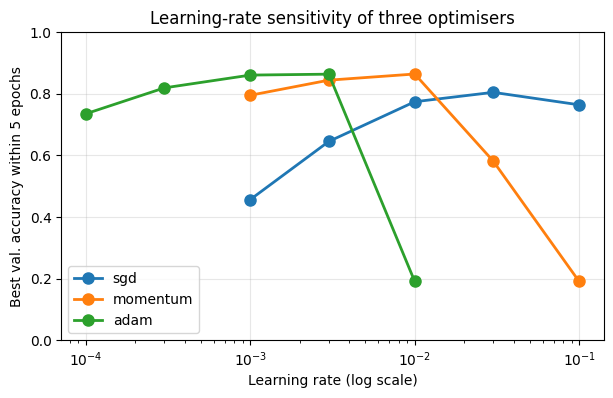

,optimizer,lr,best_val_acc,best_epoch,diverged
11,adam,0.0001,0.7350,5,False
12,adam,0.0003,0.8190,5,False
13,adam,0.0010,0.8605,5,False
14,adam,0.0030,0.8635,5,False
15,adam,0.0100,0.1905,2,False
6,momentum,0.0010,0.7950,5,False
7,momentum,0.0030,0.8440,4,False
8,momentum,0.0100,0.8640,4,False
9,momentum,0.0300,0.5815,5,False
10,momentum,0.1000,0.1905,1,False


In [48]:
log = pd.DataFrame(EXPERIMENT_LOG)
sweeps = log[log['name'].str.startswith('S_')]
plt.figure(figsize=(7, 4))
for opt_name, g in sweeps.groupby('optimizer', sort=False):
    g = g.sort_values('lr')
    plt.plot(g['lr'], g['best_val_acc'].fillna(0), 'o-', lw=2, ms=8, label=opt_name)
plt.xscale('log'); plt.ylim(0, 1)
plt.xlabel('Learning rate (log scale)'); plt.ylabel(f'Best val. accuracy within {SWEEP_EPOCHS} epochs')
plt.title('Learning-rate sensitivity of three optimisers'); plt.legend(); plt.grid(alpha=0.3)
plt.show()
sweeps[['optimizer', 'lr', 'best_val_acc', 'best_epoch', 'diverged']].sort_values(['optimizer', 'lr'])

In [49]:
# Sensitivity measure: how many orders of magnitude of learning rate give an accuracy within
# 2 percentage points of that optimiser's best? (Wider = less sensitive.)
# On a grid with factor ~3 (half a decade) between values, each grid point counts as 0.5 decade.
for opt_name, g in sweeps.groupby('optimizer', sort=False):
    acc = g['best_val_acc'].fillna(0)
    good = g[acc >= acc.max() - 0.02]
    width = np.log10(good['lr'].max() / good['lr'].min()) if len(good) > 1 else 0.0
    print(f'{opt_name:<9} best {acc.max():.3f} at lr={g.loc[acc.idxmax(), "lr"]:g}  |  '
          f'{len(good)} of {len(g)} grid values within 2 pp  ->  good region spans {width:.1f} decades')

sgd       best 0.804 at lr=0.03  |  1 of 5 grid values within 2 pp  ->  good region spans 0.0 decades
momentum  best 0.864 at lr=0.01  |  2 of 5 grid values within 2 pp  ->  good region spans 0.5 decades
adam      best 0.864 at lr=0.003  |  2 of 5 grid values within 2 pp  ->  good region spans 0.5 decades


**Questions:**

1. Which optimiser reaches the highest accuracy in 5 epochs? Is the difference larger than the noise
   floor from Lab 6 (about ±1 pp)?
2. Is the "Adam is less sensitive to the learning rate" claim supported by *your* measure? Would a
   different reasonable measure change the conclusion?
3. Compare the best learning rates for plain SGD and SGD + momentum. Explain the ratio using
   the momentum update rule. (Hint: what is the size of the velocity when the gradient is constant?)
4. Is any optimiser's best learning rate at the **edge** of its grid (slide 77)? What should you do
   if so?

> ### ✅ Solution and discussion
> **Reference runs** (5 epochs, 1 seed; best validation accuracy; values from up to three runs, separated by "/"):
>
> | lr | SGD | Momentum | Adam |
> |---|---|---|---|
> | 1e-4 | – | – | 72.2 / 72.9 / 73.5% |
> | 3e-4 | – | – | 82.1 / 81.4 / 81.9% |
> | 1e-3 | 46.2 / 45.7% | 79.2 / 79.2 / 79.5% | 85.3 / 85.0 / 86.1% |
> | 3e-3 | 67.0 / 64.5% | 84.1 / 84.5 / 84.4% | **85.3 / 85.5 / 86.4%** |
> | 1e-2 | 79.5 / 79.9 / 77.4% | **86.3 / 86.6 / 86.4%** | 18.9 / 53.8 / 19.1% |
> | 3e-2 | **78.2 / 81.2 / 80.4%** | 19.1 / 20.5 / 58.2% | – |
> | 1e-1 | 63.0 / 62.3 / 76.4% | 19.1 / 19.1 / 19.1% | – |
> | 3e-1 | 19.1% | – | – |
>
> Two robust features: (1) the **cliff**: each optimiser drops within one or two grid steps from its best value to "stuck at the majority class" (≈ 19%), without producing NaN. (2) **Values well inside the good region are very reproducible** (momentum at 1e-2: 86.3 / 86.6 / 86.4%), while values *at* the cliff vary wildly between runs (momentum at 3e-2: 19.1 / 20.5 / 58.2%; Adam at 1e-2: 18.9 / 53.8 / 19.1%).
>
> 1. Momentum (≈ 86.4%) and Adam (≈ 86%) are equal within noise; plain SGD is clearly slower within 5 epochs (≈ 80%). The lecture's message holds: SGD + momentum *can* match or beat Adam, but it needs its learning rate tuned.
> 2. With "within 2 pp of the best", the runs give: Adam 0.5 decades every time; momentum 0 or 0.5 decades; SGD 0.5 or 0 decades. **The measure itself flips between runs**, depending on whether one grid point lands just inside or just outside the 2 pp tolerance. So the claim is at best weakly supported. Note that (a) the conclusion depends on *k* and the grid spacing (a factor of ~3 is coarse), (b) one seed per point is noisy, and (c) all three optimisers share the same sharp cliff on the high side, so Adam is not robust to a too-high learning rate either.
> 3. With a constant gradient g, the velocity converges to g/(1 − ρ) = **10·g** for ρ = 0.9, so SGD + momentum with lr η "should" behave like plain SGD with lr 10·η. **The data only partly agree.** Plain SGD's best value (0.03) is ~3× momentum's (0.01), not 10×. And plain SGD at 0.1, the "equivalent" of momentum at 0.01, reached 62–76%, not 86%. The 10× argument assumes a constant gradient; with noisy mini-batch gradients, momentum also *averages out* the noise, which a 10× larger plain-SGD step cannot do. The failure boundary is more consistent with the theory: momentum fails from 0.03, plain SGD at 0.3. A good example of a theoretical argument being only approximately right in practice.
> 4. In the first reference run, plain SGD's best value was at the **lower edge** of the grid, which led us to extend the grid (slide 77). With the current grids every optimiser's best value is interior. If your best value is at an edge, extend the grid before concluding anything.

---
## Part 3: The learning-rate range test

Part 2 needed 15 training runs to locate good learning rates. The **LR range test** (slide 29) does
it in a fraction of a single run: train for a few hundred steps while increasing the learning rate
exponentially from `lr_min` to `lr_max`, and record the loss at each step.

### 🛠️ Task 3 — implement `lr_range_test`

- After `num_steps` steps the learning rate must have grown from `lr_min` to `lr_max`, so the
  multiplication factor per step is γ = (lr_max / lr_min)^(1 / num_steps).
- The raw mini-batch loss is noisy, so record an **exponential moving average** of it, with
  bias correction (the same correction as in Adam!): avg ← β·avg + (1 − β)·loss, smoothed = avg / (1 − β^(step+1)).
- Stop early when the smoothed loss exceeds 4× the lowest smoothed loss so far (it's diverging), or is not finite.

In [50]:
def lr_range_test(optimizer_name, lr_min=1e-5, lr_max=1.0, num_steps=1000, beta=0.98, seed=0):
    set_seed(seed)
    model = build_model()
    optimizer = make_optimizer(optimizer_name, model.parameters(), lr=lr_min)
    gamma = (lr_max / lr_min) ** (1 / num_steps)
    lrs, losses = [], []
    avg, best, step = 0.0, float('inf'), 0
    model.train()
    while True:
        for xb, yb in batches(x_train, y_train):
            lr = lr_min * gamma ** step
            for group in optimizer.param_groups:
                group['lr'] = lr
            optimizer.zero_grad()
            loss = plain_ce(model(xb), yb)
            loss.backward()
            optimizer.step()

            avg = beta * avg + (1 - beta) * loss.item()
            smoothed = avg / (1 - beta ** (step + 1))
            lrs.append(lr)
            losses.append(smoothed)
            best = min(best, smoothed)
            step += 1
            if (not math.isfinite(smoothed)) or smoothed > 4 * best or step >= num_steps:   # diverging, or done
                return np.array(lrs), np.array(losses)

Three range tests took 34s


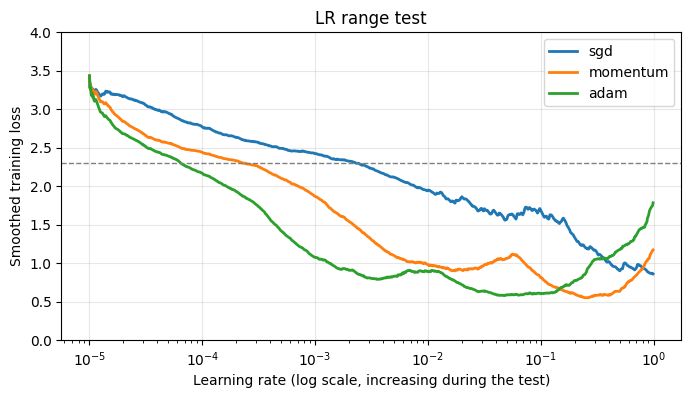

In [51]:
t0 = time.time()
range_results = {name: lr_range_test(name) for name in ['sgd', 'momentum', 'adam']}
print(f'Three range tests took {time.time() - t0:.0f}s')

plt.figure(figsize=(8, 4))
for name, (lrs, losses) in range_results.items():
    plt.plot(lrs, losses, lw=2, label=name)
plt.xscale('log'); plt.ylim(0, 4)
plt.axhline(math.log(NUM_CLASSES), color='gray', ls='--', lw=1)
plt.xlabel('Learning rate (log scale, increasing during the test)'); plt.ylabel('Smoothed training loss')
plt.title('LR range test'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Questions:**

1. For each optimiser, read off (a) the learning rate where the loss falls fastest and (b) where it
   starts to diverge. A common rule of thumb is to choose a value roughly **one order of magnitude
   below the divergence point**. What does that give you?
2. Compare with the best learning rates from your Part 2 sweep. Do they agree? Compute the cost
   of each method (in training steps).
3. Why can the range test be misleading for a dataset like SVHN, with its long initial plateau?
   (Recall Lab 6.) What does it measure that a full sweep doesn't, and vice versa?
4. Look at the **start** of the curves. The dashed line is ln(10) ≈ 2.30. Which sanity check from Lab 6
   does this fail, and what in `build_model` causes it? (Hint: which layer is Kaiming-initialised
   although no ReLU follows it?) Could this be related to training failures you have seen today?

> ### ✅ Solution and discussion
> 1. **Reference runs (1,000 steps from 1e-5; the curves were nearly identical in two runs):** all curves start at ≈ 3.4 (see question 4), fall steadily, and never "explode", so the 4× stopping rule never triggers; the tests run to lr = 1. The informative features are where each curve **stops falling or turns up**: momentum shows a bump at **≈ 3e-2 to 6e-2**, exactly where the sweep fell off its cliff; plain SGD is noisy around 3e-2 to 0.1; Adam only rises steadily above ≈ 0.2, although the sweep failed at 1e-2. One decade below the turn-up gives ≈ 3e-3 for momentum and ≈ 1e-2 for SGD, slightly *below* the sweep's best values, which is the usual, conservative outcome of that rule of thumb. The Adam mismatch is an instructive failure of the method (question 3): by the time its learning rate reaches 1e-2, the model has already trained for ~600 steps and is past the plateau, so it tolerates a learning rate that kills a freshly initialised model.
> 2. Good **order-of-magnitude** agreement, especially for the *upper limit*. Cost: 1,000 steps ≈ 6 epochs per optimiser, vs. 5 runs × 5 epochs = 25 epochs per optimiser in the sweep, i.e. ~4× cheaper (and the sweep only had 5 points). That makes it most valuable for projects where one run takes an hour.
> 3. The range test measures how fast the loss falls **in the first few hundred steps, from initialisation, with a changing learning rate**. The curve is also history-dependent: the loss at a given learning rate depends on everything learned at the lower rates before it. On SVHN, the early plateau can hide the low end: at small learning rates nothing seems to happen, not because they are useless but because the plateau hasn't been escaped yet. So the test is biased towards learning rates that are good *early*. A sweep measures the outcome after real training (and validation accuracy, not training loss), but costs much more. Use the range test to find the right **decade**, then confirm with a few full runs.
> 4. The initial loss is ≈ **3.4**, not ln(10) ≈ 2.30, so it fails **Check C (initial loss)** from Lab 6. The cause: `build_model` applies Kaiming initialisation (gain √2, designed for layers *followed by a ReLU*) to the final `nn.Linear` as well. The logits are therefore too large at initialisation and the model starts out confidently wrong. The usual fix is to initialise the last layer with small weights (e.g. N(0, 0.01²)) or zeros. Large initial logits produce large early gradients, which plausibly contribute to the collapses at higher learning rates. That is a *hypothesis*, and testing it (one change: the final-layer init) would be a nice extension or a good example of a next iteration.

---
## Part 4: Learning-rate schedules and warm-up

### 🛠️ Task 4 — implement cosine decay with linear warm-up

`warmup_cosine(step, total_steps, warmup_steps)` returns a **multiplier** for the base learning rate
(PyTorch's `LambdaLR` multiplies it with the optimiser's `lr`):

- during warm-up (`step < warmup_steps`): increase linearly, so that the multiplier is
  `(step + 1) / warmup_steps`, reaching 1 at the end of warm-up;
- afterwards: cosine decay from 1 to 0 over the remaining steps:
  0.5 · (1 + cos(π · progress)), where progress goes from 0 to 1.

In [52]:
def warmup_cosine(step, total_steps, warmup_steps):
    if warmup_steps > 0 and step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)   # 0 at the end of warm-up, 1 at total_steps
    return 0.5 * (1 + math.cos(math.pi * min(1.0, progress)))

All warmup_cosine tests passed.


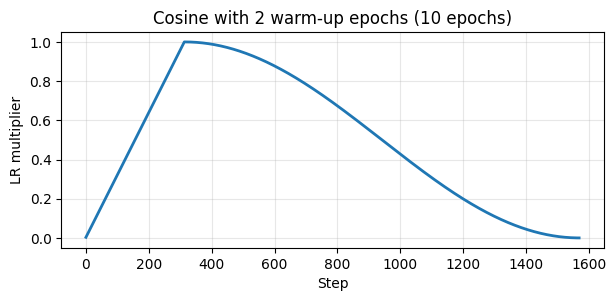

In [53]:
# Tests for Task 4
assert abs(warmup_cosine(0, 1000, 100) - 0.01) < 1e-9, 'warm-up should start at 1/warmup_steps'
assert abs(warmup_cosine(99, 1000, 100) - 1.0) < 1e-9, 'warm-up should reach 1 at its last step'
assert abs(warmup_cosine(100, 1000, 100) - 1.0) < 1e-9, 'cosine should start at 1'
assert abs(warmup_cosine(550, 1000, 100) - 0.5) < 1e-9, 'half-way through the decay should be 0.5'
assert warmup_cosine(1000, 1000, 100) < 1e-9, 'should reach 0 at the end'
assert abs(warmup_cosine(0, 1000, 0) - 1.0) < 1e-9, 'without warm-up, start at 1'
mult = [warmup_cosine(s, 1000, 100) for s in range(100, 1001)]
assert all(a >= b for a, b in zip(mult, mult[1:])), 'should decrease monotonically after warm-up'
print('All warmup_cosine tests passed.')

steps = np.arange(EPOCHS * math.ceil(N_TRAIN / BATCH_SIZE))
plt.figure(figsize=(7, 2.8))
plt.plot(steps, [warmup_cosine(s, len(steps), 2 * math.ceil(N_TRAIN / BATCH_SIZE)) for s in steps], lw=2)
plt.xlabel('Step'); plt.ylabel('LR multiplier'); plt.title(f'Cosine with 2 warm-up epochs ({EPOCHS} epochs)')
plt.grid(alpha=0.3); plt.show()

### Two experiments

**E1 — does a schedule help?** Constant learning rate vs. cosine decay, same base learning rate,
10 epochs, 2 seeds.

**E2 — does warm-up rescue a learning rate that's too high?** One claim from the lecture (slides 7 and
33) is that warm-up lets you start with a higher learning rate. **Choose** `HIGH_LR` from your Part 2
sweep or Part 3 range test: a learning rate that *diverged, or got stuck at the majority class (~19%)*, for SGD + momentum.
Then compare it with and without 2 warm-up epochs.

✍️ **Predictions:** write them down for E1 and E2 before running.

In [54]:
BASE_LR = 0.01     # best SGD + momentum lr in the reference sweep (86.3%); 0.03 already failed, so 0.01 is the safe choice
HIGH_LR = 0.03     # the first value that failed (stuck at 19.1%) for SGD + momentum in the reference sweep

In [55]:
for seed in [0, 1]:
    run_experiment('L0_constant', lr=BASE_LR, seed=seed)
    run_experiment('L1_cosine', lr=BASE_LR, schedule='cosine', seed=seed)
for seed in [0, 1]:
    run_experiment('W0_high_lr_constant', lr=HIGH_LR, seed=seed)
    run_experiment('W1_high_lr_cosine_no_warmup', lr=HIGH_LR, schedule='cosine', seed=seed)
    run_experiment('W2_high_lr_cosine_warmup2', lr=HIGH_LR, schedule='cosine', warmup_epochs=2, seed=seed)

summarise(['L0_constant', 'L1_cosine', 'W0_high_lr_constant', 'W1_high_lr_cosine_no_warmup', 'W2_high_lr_cosine_warmup2'])

  [L0_constant | seed 0] best val acc 0.890 (epoch 10) | final val acc 0.890 | clean train loss 0.002 | val loss 0.485 | 19s
  [L1_cosine | seed 0] best val acc 0.878 (epoch 6) | final val acc 0.878 | clean train loss 0.023 | val loss 0.474 | 20s
  [L0_constant | seed 1] best val acc 0.891 (epoch 8) | final val acc 0.890 | clean train loss 0.006 | val loss 0.447 | 19s
  [L1_cosine | seed 1] best val acc 0.881 (epoch 9) | final val acc 0.878 | clean train loss 0.058 | val loss 0.431 | 19s
  [W0_high_lr_constant | seed 0] best val acc 0.815 (epoch 10) | final val acc 0.815 | clean train loss 0.377 | val loss 0.579 | 19s
  [W1_high_lr_cosine_no_warmup | seed 0] best val acc 0.680 (epoch 10) | final val acc 0.680 | clean train loss 0.892 | val loss 1.007 | 19s
  [W2_high_lr_cosine_warmup2 | seed 0] best val acc 0.905 (epoch 8) | final val acc 0.904 | clean train loss 0.005 | val loss 0.406 | 19s
  [W0_high_lr_constant | seed 1] WARNING: stuck at the majority class (best val acc 0.191) -- t

,runs,best_val_acc,best_val_acc_std,final_val_acc,best_epoch,train_loss,val_loss,weight_norm,val_confidence,overconfidence,gap (val - train loss)
name,,,,,,,,,,,
L0_constant,2,0.8910,0.0007,0.8905,9.0,0.0043,0.4659,38.3951,0.9337,0.0427,0.4617
L1_cosine,2,0.8798,0.0025,0.8780,7.5,0.0405,0.4522,37.9069,0.9120,0.0322,0.4117
W0_high_lr_constant,2,0.5028,0.4416,0.5028,5.5,1.3061,1.4093,41.3860,0.5204,0.0176,0.1032
W1_high_lr_cosine_no_warmup,2,0.4352,0.3461,0.4352,5.5,1.5630,1.6227,40.3069,0.4298,-0.0055,0.0597
W2_high_lr_cosine_warmup2,2,0.9060,0.0014,0.9055,8.5,0.0047,0.4143,39.8098,0.9481,0.0421,0.4096


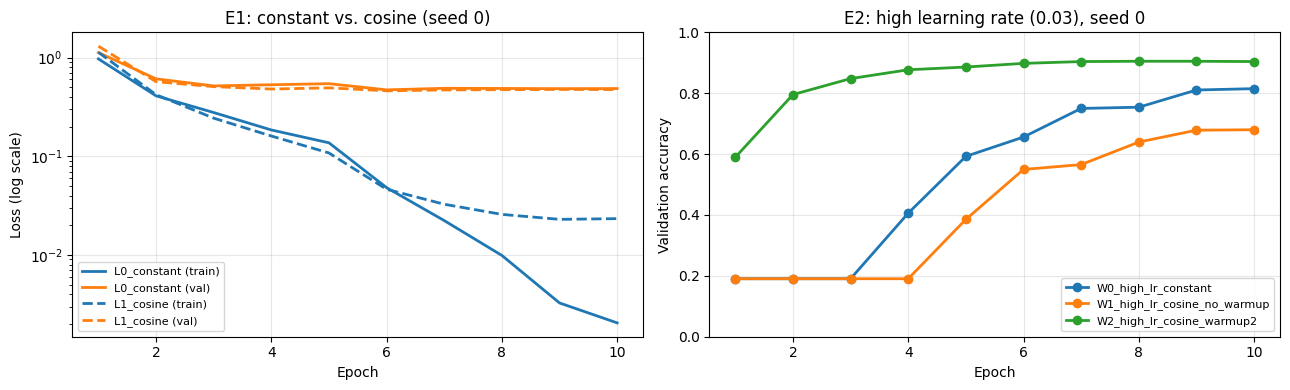

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, ls in [('L0_constant', '-'), ('L1_cosine', '--')]:
    h = HISTORIES[(name, 0)]
    ep = range(1, len(h['val_loss']) + 1)
    axes[0].plot(ep, h['train_loss'], ls, color='C0', lw=2, label=f'{name} (train)')
    axes[0].plot(ep, h['val_loss'], ls, color='C1', lw=2, label=f'{name} (val)')
axes[0].set_yscale('log'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('E1: constant vs. cosine (seed 0)'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
for name in ['W0_high_lr_constant', 'W1_high_lr_cosine_no_warmup', 'W2_high_lr_cosine_warmup2']:
    h = HISTORIES[(name, 0)]
    axes[1].plot(range(1, len(h['val_acc']) + 1), h['val_acc'], 'o-', lw=2, label=name)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation accuracy'); axes[1].set_ylim(0, 1)
axes[1].set_title(f'E2: high learning rate ({HIGH_LR:g}), seed 0'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Questions:**

1. E1: Does cosine decay improve the *best* validation accuracy, the *final* one, or neither? What
   happens to the training loss in the last epochs, and why? Does a schedule fix the overfitting from Part 1?
2. E2: Is the hypothesis "warm-up rescues a learning rate that's too high" supported? Separate
   the effect of the *decay* (W1 vs. W0) from the effect of the *warm-up* (W2 vs. W1). Why does
   this need three runs and not two?
3. When would warm-up matter more than here? (Think about Adam's early steps, large batch sizes, or
   fine-tuning a pretrained model with a freshly initialised head.)

> ### ✅ Solution and discussion
> **Reference runs** (BASE_LR = 0.01, HIGH_LR = 0.03, 10 epochs, 2 seeds; two runs, separated by "/"):
>
> | Run | Best val. acc. | Notes |
> |---|---|---|
> | L0 constant, lr 0.01 | 89.3 ± 0.2% / 89.1 ± 0.1% | clean training loss ≈ 0.004 |
> | L1 cosine, lr 0.01 | 88.0 ± 1.1% / 88.0 ± 0.3% | ends at training loss 0.04–0.08: under-trained |
> | W0 constant, lr 0.03 | 43.9% / 50.3% | in both runs one seed stuck (19.1%); the other 68.8% / 81.5% |
> | W1 cosine, no warm-up, lr 0.03 | 42.6% / 43.5% | one seed stuck; the other 65.6% / 68.0% |
> | W2 cosine + 2 warm-up epochs, lr 0.03 | **90.4 ± 0.3% / 90.6 ± 0.1%** | best configuration of the lab, in both runs |
>
> (An earlier run with BASE_LR = 0.03 showed how fragile a learning rate next to the cliff is: the same configuration got stuck for one seed and reached 80% for the other.)
>
> 1. **Cosine was *worse* than constant here** (88.0% vs. 89.1–89.3%, in both runs). With a modest base learning rate (0.01) and only 10 epochs, cosine lowers the learning rate before the model has finished fitting; both runs ended with a clearly higher training loss. A schedule isn't automatically better: it interacts with the base learning rate and the budget. It's also not a regulariser: it doesn't close the train/val gap. The right comparison for a schedule is often *at a higher base learning rate*, which is exactly what E2 shows.
> 2. **Clearly supported, in both reference runs.** W0 and W1 fail in one seed and are poor in the other; W2 trains reliably (90.2–90.7% for all four seeds) and gives the best result of the lab. Separating the effects: W1 vs. W0 (adding the decay alone) doesn't help, so the failure happens early, before the decay matters. W2 vs. W1 (adding warm-up) is the whole difference. Three runs are needed because cosine-with-warm-up changes two things at once; W1 isolates the decay, so W2 vs. W1 isolates the warm-up ("one conceptual change at a time"). Bonus insight: the *best* configuration uses the learning rate that failed without warm-up. Higher learning rates often generalise better once training is stable. **Your results will differ depending on the HIGH_LR you chose; what matters is that you interpret W0/W1/W2 correctly.**
> 3. Warm-up matters most when the first updates are unreliable or extreme: (a) **Adam**, whose second-moment estimate v is based on very few gradients early on; (b) **large batch sizes**, trained with a correspondingly large learning rate; (c) **fine-tuning** a pretrained backbone with a randomly initialised head, where large early gradients from the random head can wreck the pretrained features; (d) transformers, where it is almost always used (Lecture 12). Here it mattered because of SVHN's plateau and the oversized initial logits (Part 3, question 4).

---
## Part 5: Regularisation — designing your own ladder

### 🛠️ Task 5a — implement Mixup and Cutout

**Mixup** (slide 61): blend each image with another random image from the same batch, using a
weight λ ~ Beta(α, α). The loss is the same blend of the two cross-entropies, which the harness
already does: `lam * CE(logits, y_a) + (1 - lam) * CE(logits, y_b)`.

**Cutout** (slide 60): set a random `size × size` square in each image to 0. After normalisation,
0 is the mean colour, so this "greys out" a patch. The square's centre is drawn uniformly over the
image, so it may be partly outside (clip it at the borders).

In [58]:
def mixup(xb, yb, alpha):
    '''Returns (mixed images, labels of the first images, labels of the second images, lambda).'''
    lam = float(np.random.beta(alpha, alpha))
    perm = torch.randperm(len(xb), device=xb.device)
    x_mix = lam * xb + (1 - lam) * xb[perm]
    return x_mix, yb, yb[perm], lam


def cutout(xb, size=12):
    '''Zeroes one random size x size square (clipped at the borders) in every image.'''
    n, _, h, w = xb.shape
    cy = torch.randint(0, h, (n,), device=xb.device)
    cx = torch.randint(0, w, (n,), device=xb.device)
    ys = torch.arange(h, device=xb.device).view(1, h, 1)
    xs = torch.arange(w, device=xb.device).view(1, 1, w)
    inside = ((ys - cy.view(n, 1, 1)).abs() < size / 2) & ((xs - cx.view(n, 1, 1)).abs() < size / 2)
    return xb * (~inside).unsqueeze(1).float()

All Mixup/Cutout tests passed.


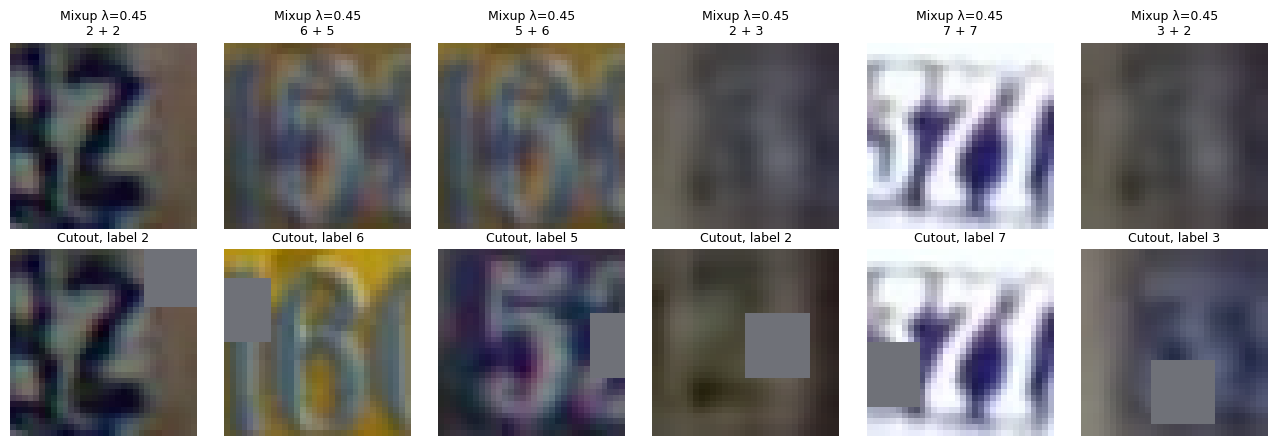

In [59]:
# Tests for Task 5a
torch.manual_seed(0); np.random.seed(0)
xb, yb = x_train[:8], y_train[:8]
x_mix, y_a, y_b, lam = mixup(xb, yb, alpha=0.4)
assert x_mix.shape == xb.shape and 0 <= lam <= 1
assert torch.equal(y_a, yb) and sorted(y_b.tolist()) == sorted(yb.tolist()), 'y_b should be the same labels, permuted'
other = (x_mix - lam * xb) / (1 - lam)                               # should recover the partner images
for i in range(len(xb)):
    assert any(torch.allclose(other[i], xb[j], atol=1e-3) and y_b[i] == yb[j] for j in range(len(xb))), \
        f'image {i}: x_mix must be lam * x + (1 - lam) * x_partner, with y_b the partner label'

x_cut = cutout(xb, size=12)
zeroed = (x_cut == 0).all(dim=1).float().sum(dim=(1, 2))           # zeroed pixels per image
assert (zeroed > 0).all() and (zeroed <= 144).all(), f'each image should lose 1-144 pixels, got {zeroed.tolist()}'
assert torch.equal(x_cut[x_cut != 0], xb[x_cut != 0]), 'pixels outside the square must be unchanged'
print('All Mixup/Cutout tests passed.')

fig, axes = plt.subplots(2, 6, figsize=(13, 4.5))
show = lambda t: ((t.cpu() * STD[0] + MEAN[0]).clamp(0, 1)).permute(1, 2, 0).numpy()
x_mix, y_a, y_b, lam = mixup(xb[:6], yb[:6], alpha=1.0)
for i in range(6):
    axes[0, i].imshow(show(x_mix[i])); axes[0, i].set_title(f'Mixup λ={lam:.2f}\n{y_a[i].item()} + {y_b[i].item()}', fontsize=9)
    axes[1, i].imshow(show(cutout(xb[i:i + 1])[0])); axes[1, i].set_title(f'Cutout, label {yb[i].item()}', fontsize=9)
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout(); plt.show()

### What are we actually testing?

Every regulariser in the lecture works through a specific **mechanism**, and each mechanism can be
measured directly:

| Technique | What it is designed to do | Measured by |
|---|---|---|
| Weight decay | keep the weights small | `weight_norm` ↓ |
| Label smoothing, Mixup | stop the model from becoming overconfident | `val_confidence` ↓, `overconfidence` ↓ |
| Shift augmentation, Cutout, Mixup | make the training set harder to memorise | clean `train_loss` ↑, `gap (val − train loss)` ↓ |
| Dropout | prevent co-adaptation of features in the FC layer | train–val gap ↓ |

Whether the mechanism then **improves validation accuracy** is a separate question. It depends on
whether that mechanism addresses what actually limits accuracy in *this* setting, and on whether the
training budget is long enough for the benefit to appear. So in this part you test **two hypotheses
per technique**: (a) the mechanism happens, and (b) accuracy improves. Expect (a) to hold. Be ready to
explain (b), whichever way it goes.

Remember the limits of this setup (see the introduction): a small network, 2,000 images and 30 epochs.
Many of these techniques are known to pay off with longer training. A negative result here is a
finding about this setup, not a verdict on the technique.

### A small-data project

Regularisation matters most when **data is scarce** compared with the model's capacity, which is
the situation many of your projects are in. So we simulate a small-data project: **2,000 training
images** (the first 2,000 of our training set), trained for **30 epochs**. Each run takes ~15 s. The
validation set is unchanged.

### 🛠️ Task 5b — design your regularisation experiments

You have a budget of **12 runs** (`R0_base` plus at least four single changes, 2 seeds each). Start
from a robust optimiser, learning rate and schedule from Parts 2–4 (`BASE`). If `R0_base` gets stuck
at ~19% for any seed, every comparison becomes meaningless. (With 2,000 images an epoch has only 32
steps, so "2 warm-up epochs" means far fewer warm-up steps than in Part 4.)

**Before running**, fill in this prediction table in a markdown cell, one row per experiment:

| Experiment | Strength | Mechanism metric | ✍️ Predicted change in the metric | ✍️ Predicted change in best val. accuracy |
|---|---|---|---|---|
| R1_… | | | | |

Choose sensible strengths yourself (e.g. weight decay 1e-4 to 1e-3, dropout 0.3 to 0.5, Mixup α 0.2 to
0.4, label smoothing 0.1).

In [60]:
BASE = dict(optimizer='momentum', lr=0.01, schedule='cosine', warmup_epochs=0)   # lr 0.01 never failed in any run

LADDER = {
    'R0_base': dict(),
    'R1_weight_decay_5e-4': dict(weight_decay=5e-4),
    'R3_shift_aug': dict(augment=True),
    'R4_mixup_0.2': dict(mixup_alpha=0.2),
    'R5_label_smooth_0.1': dict(label_smoothing=0.1),
    'R6_cutout_12': dict(cutout=True),
}

N_SMALL, EPOCHS_SMALL = 2_000, 30
for name, change in LADDER.items():
    for seed in [0, 1]:
        run_experiment(name, seed=seed, epochs=EPOCHS_SMALL, train_size=N_SMALL, **{**BASE, **change})
summarise(list(LADDER))

  [R0_base | seed 0] best val acc 0.798 (epoch 24) | final val acc 0.795 | clean train loss 0.005 | val loss 0.876 | 16s
  [R0_base | seed 1] best val acc 0.777 (epoch 14) | final val acc 0.773 | clean train loss 0.004 | val loss 0.907 | 17s
  [R1_weight_decay_5e-4 | seed 0] best val acc 0.804 (epoch 26) | final val acc 0.804 | clean train loss 0.005 | val loss 0.811 | 17s
  [R1_weight_decay_5e-4 | seed 1] best val acc 0.785 (epoch 23) | final val acc 0.783 | clean train loss 0.005 | val loss 0.864 | 16s
  [R3_shift_aug | seed 0] best val acc 0.721 (epoch 30) | final val acc 0.721 | clean train loss 0.366 | val loss 0.887 | 16s
  [R3_shift_aug | seed 1] best val acc 0.814 (epoch 28) | final val acc 0.813 | clean train loss 0.080 | val loss 0.664 | 17s
  [R4_mixup_0.2 | seed 0] best val acc 0.757 (epoch 21) | final val acc 0.754 | clean train loss 0.075 | val loss 0.830 | 17s
  [R4_mixup_0.2 | seed 1] best val acc 0.779 (epoch 23) | final val acc 0.776 | clean train loss 0.091 | val los

,runs,best_val_acc,best_val_acc_std,final_val_acc,best_epoch,train_loss,val_loss,weight_norm,val_confidence,overconfidence,gap (val - train loss)
name,,,,,,,,,,,
R0_base,2,0.7877,0.0145,0.7845,19.0,0.0045,0.8918,37.6250,0.8786,0.0908,0.8872
R1_weight_decay_5e-4,2,0.7948,0.0131,0.7935,24.5,0.0051,0.8378,36.7844,0.8806,0.0859,0.8327
R3_shift_aug,2,0.7670,0.0658,0.7668,29.0,0.2228,0.7759,37.5881,0.7979,0.0309,0.5531
R4_mixup_0.2,2,0.7685,0.0156,0.7650,22.0,0.0831,0.8075,37.5482,0.7126,-0.0559,0.7244
R5_label_smooth_0.1,2,0.7418,0.0074,0.7370,16.0,0.1019,0.9074,37.4134,0.6411,-0.1006,0.8054
R6_cutout_12,2,0.7748,0.0209,0.7725,26.5,0.0424,0.7878,37.6054,0.8244,0.0496,0.7455


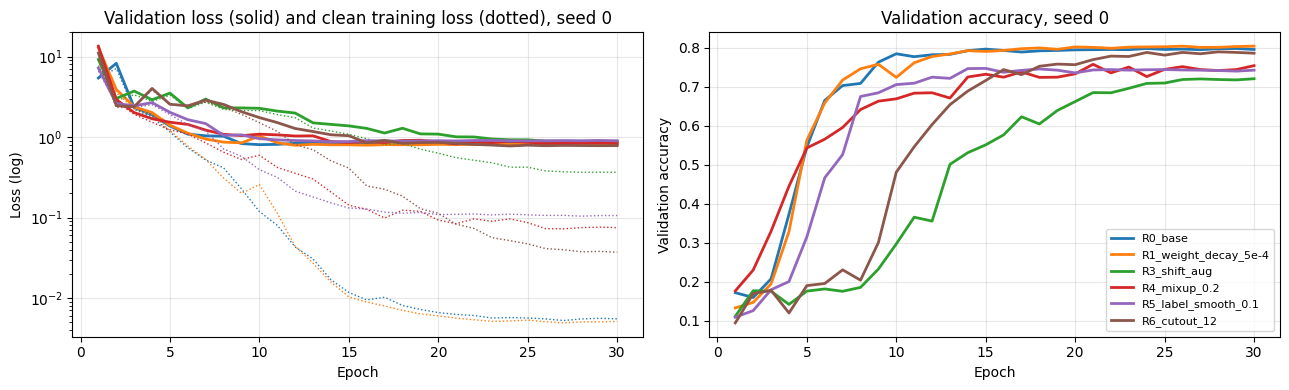

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, name in enumerate(LADDER):
    h = HISTORIES[(name, 0)]
    ep = range(1, len(h['val_loss']) + 1)
    axes[0].plot(ep, h['val_loss'], lw=2, color=f'C{i}', label=name)
    axes[0].plot(ep, h['train_loss'], lw=1, ls=':', color=f'C{i}')
    axes[1].plot(ep, h['val_acc'], lw=2, color=f'C{i}', label=name)
axes[0].set_yscale('log'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (log)')
axes[0].set_title('Validation loss (solid) and clean training loss (dotted), seed 0')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation accuracy'); axes[1].set_title('Validation accuracy, seed 0')
for ax in axes:
    ax.grid(alpha=0.3)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### The "regulariser" the lecture calls the best: more data

For comparison, train the *unregularised* base model on all **10,000** images for 6 epochs. That's the
same number of gradient steps (and images seen) as 30 epochs on 2,000 images. Only the number of
*distinct* images changes.

In [62]:
for seed in [0, 1]:
    run_experiment('R_more_data_10k', seed=seed, epochs=EPOCHS_SMALL * N_SMALL // N_TRAIN, train_size=None, **BASE)
summarise(list(LADDER) + ['R_more_data_10k'])

  [R_more_data_10k | seed 0] best val acc 0.875 (epoch 6) | final val acc 0.875 | clean train loss 0.110 | val loss 0.453 | 11s
  [R_more_data_10k | seed 1] best val acc 0.806 (epoch 6) | final val acc 0.806 | clean train loss 0.423 | val loss 0.642 | 12s


,runs,best_val_acc,best_val_acc_std,final_val_acc,best_epoch,train_loss,val_loss,weight_norm,val_confidence,overconfidence,gap (val - train loss)
name,,,,,,,,,,,
R0_base,2,0.7877,0.0145,0.7845,19.0,0.0045,0.8918,37.6250,0.8786,0.0908,0.8872
R1_weight_decay_5e-4,2,0.7948,0.0131,0.7935,24.5,0.0051,0.8378,36.7844,0.8806,0.0859,0.8327
R3_shift_aug,2,0.7670,0.0658,0.7668,29.0,0.2228,0.7759,37.5881,0.7979,0.0309,0.5531
R4_mixup_0.2,2,0.7685,0.0156,0.7650,22.0,0.0831,0.8075,37.5482,0.7126,-0.0559,0.7244
R5_label_smooth_0.1,2,0.7418,0.0074,0.7370,16.0,0.1019,0.9074,37.4134,0.6411,-0.1006,0.8054
R6_cutout_12,2,0.7748,0.0209,0.7725,26.5,0.0424,0.7878,37.6054,0.8244,0.0496,0.7455
R_more_data_10k,2,0.8410,0.0488,0.8410,6.0,0.2665,0.5477,37.5946,0.8444,0.0034,0.2813


### Paired comparison

Each experiment used the same two seeds as `R0_base`, so the same initial weights and the same batch
order. Comparing each run with the `R0_base` run *of the same seed* removes some of the seed noise.
The table shows the paired difference in accuracy **and** in each mechanism metric.

In [63]:
def paired_vs(reference, names, metrics=('best_val_acc', 'weight_norm', 'val_confidence', 'final_train_loss')):
    df = pd.DataFrame(EXPERIMENT_LOG)
    rows = []
    for n in names:
        row = dict(name=n)
        for metric in metrics:
            ref = df[df['name'] == reference].set_index('seed')[metric]
            d = df[df['name'] == n].set_index('seed')[metric] - ref
            scale = 100 if metric in ('best_val_acc', 'val_confidence') else 1
            row[f'Δ {metric}' + (' (pp)' if scale == 100 else '')] = scale * d.mean()
            row[f'{metric}: same sign both seeds'] = bool((d > 0).all() or (d < 0).all())
        rows.append(row)
    return pd.DataFrame(rows).set_index('name').round(3)


paired_vs('R0_base', [n for n in list(LADDER) + ['R_more_data_10k'] if n != 'R0_base'])

,Δ best_val_acc (pp),best_val_acc: same sign both seeds,Δ weight_norm,weight_norm: same sign both seeds,Δ val_confidence (pp),val_confidence: same sign both seeds,Δ final_train_loss,final_train_loss: same sign both seeds
name,,,,,,,,
R1_weight_decay_5e-4,0.700,True,-0.841,True,0.204,True,0.001,False
R3_shift_aug,-2.075,False,-0.037,False,-8.073,True,0.218,True
R4_mixup_0.2,-1.925,False,-0.077,True,-16.603,True,0.079,True
R5_label_smooth_0.1,-4.600,True,-0.212,True,-23.747,True,0.097,True
R6_cutout_12,-1.300,True,-0.020,False,-5.422,True,0.038,True
R_more_data_10k,5.325,True,-0.030,False,-3.418,False,0.262,True


**Questions** (answer in your own words; this is the core of the lab):

1. **Mechanisms.** For each technique, did the mechanism metric change in the direction you predicted,
   consistently for both seeds? Fill in an "observed" column next to your prediction table.
2. **Accuracy.** Which techniques improved best validation accuracy by more than the noise? For each
   one that did **not**, give the most likely explanation, using evidence from the curves and the
   table. Possible explanations to consider:
   - the budget: is the regularised model still learning at epoch 30 (look at its clean training loss
     and validation curve)?
   - the mechanism doesn't address what limits accuracy here (e.g. lower confidence doesn't change
     *which* class is predicted);
   - the technique doesn't suit this dataset (think about what a 4-pixel shift or a 12×12 Cutout
     square does to a 32×32 SVHN crop with neighbouring digits);
   - the strength you chose.
3. Is a smaller train–val gap a goal in itself? Find an example in your table where the gap shrank
   but accuracy didn't improve, and explain it.
4. Compare `best_val_acc` with `final_val_acc` and `best_epoch`. With cosine decay the best epoch is
   usually (close to) the last one. Why? When does early stopping matter most?
5. **Paired comparison.** For which changes do both seeds agree in sign? Why can a paired comparison
   detect smaller effects than comparing means ± std?
6. **More data.** Compare `R_more_data_10k` with your best regulariser. What does that tell you about
   where to spend effort in your project?
7. Mixup: why is its clean training loss higher than the baseline's, and why would its training
   loss *during* training (on mixed images) be misleading?
8. If this were your project and you needed the regularisers to pay off in accuracy, what would you
   change about the experiment, and how would you know it had worked?
9. Write one Results sentence and one Discussion sentence about a technique that **did not** improve
   accuracy. Report it as a finding, not as a failure.

> ### ✅ Solution and discussion
> **Reference run** (2,000 images, 30 epochs, lr 0.01 cosine, 2 seeds). Paired Δ = difference from `R0_base` of the same seed, averaged over the 2 seeds; ✓ = both seeds agree in sign.
>
> | Experiment | Best val. acc. | Paired Δ acc. | Mechanism (paired Δ) | Clean train loss | Gap |
> |---|---|---|---|---|---|
> | R0 base | 78.8 ± 1.5% | – | conf. 0.88, overconf. +0.09, ‖W‖ 37.6 | 0.005 | 0.89 |
> | R1 weight decay 5e-4 | 79.5 ± 1.3% | **+0.7 ✓** | ‖W‖ −0.84 ✓ | 0.005 | 0.83 |
> | R3 shift augmentation | 76.7 ± 6.6% | −2.1 (seeds −7.7 / +3.6) | train loss +0.22 ✓, conf. −8 pp ✓ | 0.22 | **0.55** |
> | R4 Mixup 0.2 | 76.9 ± 1.6% | −1.9 (not ✓) | conf. −16.6 pp ✓, overconf. → −0.06 | 0.08 | 0.72 |
> | R5 label smoothing 0.1 | 74.2 ± 0.7% | −4.6 ✓ | conf. **−23.7 pp** ✓, overconf. → −0.10 | 0.10 | 0.81 |
> | R6 Cutout 12 | 77.5 ± 2.1% | −1.3 ✓ | train loss +0.04 ✓, conf. −5.4 pp ✓ | 0.04 | 0.75 |
> | More data (10k, same steps) | **84.1%** (87.6 / 80.7) | **+5.3 ✓** | – | 0.27 | – |
>
> (An earlier run gave the same overall picture: weight decay +1.2 pp, more data +7.5 pp, everything else at or below the baseline. An even earlier run also tested shift augmentation + Cutout combined: −8.3 pp, a clear case of over-regularising for the budget.)
>
> **The key message:** every technique did what it is designed to do, and the paired table shows it consistently for both seeds. But **only weight decay improved accuracy** (by under 1 pp), while **more data gave +5 pp**. Being able to explain this gap between "mechanism" and "accuracy", and to state that it is a finding about *this* toy setup, shows a better understanding of the lecture than a +2 pp gain that nobody can explain.
>
> 1. Observed, consistently for both seeds: weight decay shrinks the weight norm; label smoothing and Mixup strongly lower the confidence; augmentation and Cutout raise the clean training loss and shrink the gap (and also lower the confidence). Two subtleties worth discussing: (a) weight decay shrinks ‖W‖ by only ~2%. With batch norm after every conv layer, the network's output doesn't depend on the conv weights' scale, so weight decay mainly changes the *effective learning rate* rather than the function. (b) Label smoothing and Mixup overshoot: overconfidence goes from +0.09 to **negative** (−0.10 and −0.06), so the models become *under*confident, which is not better calibration either.
> 2. Good explanations, with evidence:
>    - **Budget, and the plateau:** look at the validation-accuracy curves. The regularised models leave SVHN's initial plateau much later; in the reference run, shift augmentation (seed 0) and Cutout only started improving around epochs 8–10, against epoch ~5 for the base. They lose a third of the budget, and their clean training loss is still 0.04–0.22 at epoch 30 (base: 0.005). That plateau timing also explains the huge seed difference for augmentation (72.1% vs. 81.4%).
>    - **The mechanism vs. the bottleneck:** label smoothing reduces *confidence*, not *which class is ranked first*. It fixes overconfidence (the validation-loss symptom from Part 1) but not the errors themselves.
>    - **Dataset fit:** SVHN crops contain neighbouring digits at the edges. A 4-pixel shift can move a neighbour towards the centre, and a 12×12 Cutout square (14% of the image) can hide most of the actual digit. Both can effectively create mislabelled training images. Strong SVHN results are often reported *without* augmentation.
>    - **Strength:** α = 0.2, ε = 0.1, Cutout 12 were not tuned; weaker settings might be neutral.
> 3. No. Shift augmentation is the clearest example: the gap shrank from 0.89 to 0.55, but mean accuracy fell. The gap shrank mainly because the *training* loss rose (a harder training task), not because validation performance improved. A smaller gap is only good if validation performance improves.
> 4. With cosine decay the learning rate goes to ~0 at the end, so the final epochs make only small, low-noise refinements; best ≈ final throughout the table (differences ≤ 0.5 pp). With a **constant** learning rate (Part 1) the model keeps moving and keeps overfitting. Early stopping matters most with constant or slowly decaying learning rates, long budgets and strong overfitting. With a schedule fitted to a fixed budget, the schedule length acts as a form of early stopping.
> 5. In the reference run, weight decay, label smoothing, Cutout and more data agree in sign for both seeds; augmentation and Mixup do not. The *mechanism* metrics agree in sign much more often than accuracy does, which is itself a nice observation: the mechanism is a large, reliable effect; the accuracy effect is small and noisy. Pairing cancels the part of the noise shared by runs with the same seed (same initial weights and batch order). With only 2 seeds it's still weak evidence: two signs agree by chance 50% of the time if there is no effect.
> 6. Five times more distinct images, at the *same* compute, gave about **7× the gain of the best regulariser** (+5.3 vs. +0.7 pp). For projects: more labelled data, a closely related extra dataset, or a pretrained model (which is "more data" in another form) is usually a better investment than tuning regularisers.
> 7. The clean training loss is measured on unmixed images, but the model was trained to output *blended* probabilities, so it's deliberately less confident → higher cross-entropy on clean images. The loss *during* training is computed against mixed targets, where even a perfect model can't reach 0, so it isn't comparable with the other runs at all.
> 8. Train much longer (e.g. 100+ epochs), with early stopping, and check that every configuration's validation curve has flattened before comparing. Tune the strength (a small grid per technique). Use more seeds (≥ 3). Choose augmentations that preserve the label for this data (e.g. smaller shifts on SVHN). It has worked if the paired accuracy differences are consistently positive *and* larger than the seed noise.
> 9. *Example:* Results: "Label smoothing (ε = 0.1) reduced the mean validation confidence from 0.88 to 0.64 but lowered best validation accuracy from 78.8 ± 1.5% to 74.2 ± 0.7% (paired difference −4.6 pp, consistent for both seeds)." Discussion: "Label smoothing removed overconfidence as intended, and even made the model underconfident, but it did not reduce the number of misclassifications. In our small setting (2,000 images, 30 epochs, a 0.5M-parameter CNN), the softened targets appear to slow down fitting; longer training would be needed to judge whether its calibration benefit can come without an accuracy cost."

---
## Part 6: Ensembles — for free

Every configuration in your ladder has been trained with 2 seeds, so you already have an
ensemble (slide 46) without training anything new. All models are stored in `MODELS[(name, seed)]`.

### 🛠️ Task 6 — implement `ensemble_accuracy`

Average the **softmax probabilities** of the models, then take the argmax. Work in batches, as
`evaluate` does: the full test set in Part 7 is too large to push through the networks in one go.

In [64]:
@torch.no_grad()
def ensemble_accuracy(models, x, y):
    for m in models:
        m.eval()
    correct = 0
    for xb, yb in batches(x, y, batch_size=512, shuffle=False):   # in batches: the test set has 26k images
        probs = torch.stack([F.softmax(m(xb), dim=1) for m in models]).mean(dim=0)   # (batch, NUM_CLASSES)
        correct += (probs.argmax(1) == yb).sum().item()
    return correct / len(y)

In [65]:
rows = []
for name in list(LADDER) + ['R_more_data_10k']:
    members = [MODELS[(name, s)] for s in [0, 1] if (name, s) in MODELS]
    singles = [evaluate(m, x_val, y_val)[1] for m in members]
    rows.append(dict(config=name, single_mean=np.mean(singles), single_best=np.max(singles),
                     ensemble_of_2=ensemble_accuracy(members, x_val, y_val)))
ens = pd.DataFrame(rows)
ens['gain_vs_mean_pp'] = 100 * (ens['ensemble_of_2'] - ens['single_mean'])
ens['gain_vs_best_pp'] = 100 * (ens['ensemble_of_2'] - ens['single_best'])

top = ens.sort_values('ensemble_of_2', ascending=False)['config'].tolist()[:3]
mixed = [MODELS[(n, s)] for n in top for s in [0, 1]]
print(f'Ensemble of all 6 models from the top-3 configs {top}: {ensemble_accuracy(mixed, x_val, y_val):.3f}')
ens.round(4)

Ensemble of all 6 models from the top-3 configs ['R_more_data_10k', 'R0_base', 'R1_weight_decay_5e-4']: 0.845


,config,single_mean,single_best,ensemble_of_2,gain_vs_mean_pp,gain_vs_best_pp
0,R0_base,0.7877,0.7980,0.8160,2.825,1.80
1,R1_weight_decay_5e-4,0.7948,0.8040,0.8080,1.325,0.40
2,R3_shift_aug,0.7670,0.8135,0.8050,3.800,-0.85
3,R4_mixup_0.2,0.7685,0.7795,0.7965,2.800,1.70
4,R5_label_smooth_0.1,0.7418,0.7470,0.7785,3.675,3.15
5,R6_cutout_12,0.7748,0.7895,0.7990,2.425,0.95
6,R_more_data_10k,0.8410,0.8755,0.8730,3.200,-0.25


**Questions:**

1. How much does a 2-model ensemble gain over a single model? Compare the gain against the **mean**
   and against the **best** single model. When can these two tell very different stories?
2. Is the ensemble of 6 models from *different* configurations better than the 2-seed ensembles? Why
   might diversity matter?
3. What does the ensemble cost at training time and at test time? When would it be worth it in your project?
4. Careful: we chose the "top-3 configs" using the validation set, and then evaluated the mixed
   ensemble *on the same validation set*. Why is that number optimistic?

> ### ✅ Solution and discussion
> **Reference runs (small-data ladder):** 2-seed ensembles gained **+0.4 to +3.2 pp over the best single model** for most configurations (e.g. R0 81.6% vs. best single 79.8%; label smoothing 77.9% vs. 74.7%). The exceptions are shift augmentation (−0.9 pp; one seed at 81.4% was much better than the other at 72.1%) and the 10k model (−0.3 pp). The 6-model ensemble from the top-3 configurations reached 84.5–85.9% in two runs. In the earlier 10k/10-epoch run the gains were smaller (+0.4 to +1.7 pp): ensembles help most when the single models are high-variance, as in the small-data regime. In an even earlier run, one configuration had a collapsed member: its ensemble showed a "+32.6 pp gain" over the *mean* but −0.3 pp against the *best* single model. **Comparing with the mean can hugely overstate an ensemble's benefit**; that's why the table shows both.
>
> 1. Typically **+1 to +3 pp** over the best single model here, more than any single regulariser achieved, at zero extra training cost. The mean and the best tell different stories when the two members differ a lot (a failed run, or high seed variance as with shift augmentation).
> 2. Not necessarily. In the reference run, the mixed top-3 ensemble (84.5%) was *below* the 2-seed ensemble of the 10k models alone (87.3%), because it averages strong 10k models with weaker 2k models. Diversity only helps if the members are comparably good: models trained with different regularisers make **less correlated errors**, but averaging in a clearly worse model drags the ensemble down.
> 3. Training: K× compute (here it was free only because we needed seeds anyway). Test time: K× inference cost and memory. Worth it when the final accuracy matters more than latency, e.g. for the final reported result. An ensemble should be **reported as an ensemble**, not compared with single models as if it were one.
> 4. Selecting the configurations on validation and then evaluating on the same validation set leaks the selection into the estimate (a mild version of "tuning on the test set"). The number is biased upwards. That's why Part 7 uses a separate, untouched test set.

---
## Part 7: The final test — exactly once

So far, every decision was made on the validation set. Now:

### 🛠️ Task 7

1. Choose your **final model**: one configuration from today (single model or 2-seed ensemble), based
   on validation results only. Write its name in `FINAL`.
2. ✍️ Write down your **predicted test accuracy** *before* running the cell, and a one-line reason why it
   might be lower (or higher) than the validation accuracy.
3. Run the cell **once**. Don't go back and change `FINAL` after seeing the result. If you do, the
   test set becomes another validation set.

In [66]:
# Rule: the configuration with the highest mean best_val_acc among those with 2 stored seed models.
df = pd.DataFrame(EXPERIMENT_LOG)
stored = {n for (n, s) in MODELS}
cand = df[df['name'].isin(stored)].groupby('name')['best_val_acc'].agg(['mean', 'count'])
FINAL = cand[cand['count'] >= 2]['mean'].idxmax()
print('FINAL =', FINAL, f'(mean best val acc {cand.loc[FINAL, "mean"]:.4f})')
PREDICTED_TEST_ACC = round(float(cand.loc[FINAL, 'mean']), 3)   # a reasonable prediction: the validation accuracy

FINAL = W2_high_lr_cosine_warmup2 (mean best val acc 0.9060)


In [67]:
svhn_test = torchvision.datasets.SVHN(root='./data', split='test', download=True)
x_test, y_test = load_subset(svhn_test, torch.arange(len(svhn_test)))
x_test, y_test = ((x_test - MEAN) / STD).to(device), y_test.to(device)   # TRAINING statistics, as always

members = [MODELS[(FINAL, s)] for s in [0, 1]]
val_single = np.mean([evaluate(m, x_val, y_val)[1] for m in members])
test_single = [evaluate(m, x_test, y_test)[1] for m in members]
print(f'Final model: {FINAL}   (test set: {len(y_test):,} images)')
print(f'  validation accuracy (mean of 2 seeds): {val_single:.4f}')
print(f'  test accuracy, single models:          {test_single[0]:.4f}, {test_single[1]:.4f}')
print(f'  test accuracy, 2-seed ensemble:        {ensemble_accuracy(members, x_test, y_test):.4f}')
print(f'  your prediction:                       {PREDICTED_TEST_ACC:.4f}')

Final model: W2_high_lr_cosine_warmup2   (test set: 26,032 images)
  validation accuracy (mean of 2 seeds): 0.9060
  test accuracy, single models:          0.9021, 0.9060
  test accuracy, 2-seed ensemble:        0.9117
  your prediction:                       0.9060


**Questions:**

1. How close was your prediction? Is the test accuracy lower or higher than the validation accuracy,
   and by more or less than you expected?
2. Give two reasons why the validation accuracy is an optimistic estimate after this lab. (Count how
   many decisions were made using the validation set.)
3. The SVHN test set (26,032 images) is 13× larger than our validation set. What does that mean for the
   uncertainty of each estimate?
4. **For your project:** when will you use your test set, and how will you make sure it's only used once?

> ### ✅ Solution and discussion
> **Reference runs:** the selection rule picked **W2** (lr 0.03, cosine, 2 warm-up epochs, all 10k images) in both runs, with a mean validation accuracy of 90.6–90.7%. Test accuracy of the single models: **90.2% and 90.6%** (90.6% and 90.7% in the other run), i.e. within ~0.5 pp of the validation estimate. The 2-seed ensemble reached **91.2%** on the test set. **Decide the selection rule before looking at the test set**; choosing a final model by hand is easy to get wrong.
>
> 1. Expect the test accuracy to be within ~1 pp of the validation accuracy, as in the reference runs (and sometimes slightly *higher*; SVHN's test split is generally considered somewhat easier than the training split). Note that the direction is not guaranteed. The ensemble gaining ~0.8 pp over the single models on the test set confirms the Part 6 result on fresh data.
> 2. (a) **Selection bias**: dozens of runs were compared and the best was selected on validation, so its validation score includes some lucky noise ("winner's curse"). (b) The **best epoch** of every run was chosen on validation. (c) Hyperparameters (learning rate, schedule, regulariser strength) were tuned on it. All three make the validation estimate optimistic; the test set is free of them. Here the effect turned out to be small (≤ 0.5 pp).
> 3. Standard error ≈ √(p(1−p)/N). At ~90%: validation (N = 2,000) ≈ ±0.67 pp, test (N = 26,032) ≈ ±0.19 pp. The test estimate is ~3.6× more precise, so the validation numbers compared all lab are much noisier than the final test number.
> 4. The test set should be used **once**, at the very end, for the final configuration(s) chosen in advance by a stated rule. It is never looked at during development; the split is fixed (and saved) before experiments start; and the report states this explicitly. If you have already looked at test results, say so honestly and, if possible, set aside a fresh held-out set.

---
## Wrapping up

New functions to copy into your project's toolbox:

| Function | Use it for |
|---|---|
| `EarlyStopping` | Every training run: keep the best checkpoint, optionally stop early |
| `lr_range_test` | Finding the right **decade** for the learning rate in one cheap run |
| `warmup_cosine` (+ `LambdaLR`) | A robust default schedule; warm-up when fine-tuning or using large learning rates |
| `mixup`, `cutout` | Regularisation for small classification datasets |
| `ensemble_accuracy` | Combining the seed runs you already have |
| `run_experiment` + log + `summarise` | Single-change comparisons, mean ± std, best vs. final epoch |

## Now: your own project

Open **`Lab7_IterationLog_Week7.md`** with your group. You will diagnose your own model's training
curves, choose the remedy that matches the diagnosis, plan your hyperparameter search, and agree on
the first experiment after the break with a TA.

Expect your project's results to differ from today's. Your network, data and budget are different,
and techniques that didn't help here may well help there, or the other way round. That's exactly why
each technique has to be tested as a single change on **your** setup, rather than adopted (or
rejected) because of this lab.